<a href="https://colab.research.google.com/github/yorkneveryueke/STAT2401_UWA/blob/main/%E2%80%9CSTAT2401_Assignment_1_ipynb%E2%80%9D_question_1_version1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STAT2401 Analysis of Experiments （R system）
Semester 1, 2026
Assignment 1 (15%, 50 marks)
---
Due date: Week 7 Friday 17th of April 2026 by 11:59pm: ➿

Team Members:
York Zhang 24473518
Yilian Wang Number.

## Question 1
Hypothesis test & Correlation ρxy
$$
t = \frac{r_{XY}\sqrt{n-2}}{\sqrt{1-r_{XY}^2}}
$$

In [ ]:
set.seed(202603)
sim_with_rho <- function(rho, n) {
  x <- rnorm(n)
  y <- rho * x + sqrt(1 - rho ^ 2) * rnorm(n)
  data.frame(x = x, y = y)
}
example_data <- sim_with_rho(0.5, 8)
print(example_data$x, digits = 3)
## [1] -1.218 -0.570  0.597 -0.138  0.578 -0.450  0.976 -0.480

print(example_data$y, digits = 3)
## [1] -0.48010 -2.10944  0.97563  1.08573  0.37540 -0.02913 -0.00666  1.12290

[1] -1.218 -0.570  0.597 -0.138  0.578 -0.450  0.976 -0.480
[1] -0.48010 -2.10944  0.97563  1.08573  0.37540 -0.02913 -0.00666  1.12290


(a) a certain n and rho and comments

[1] -0.7750332

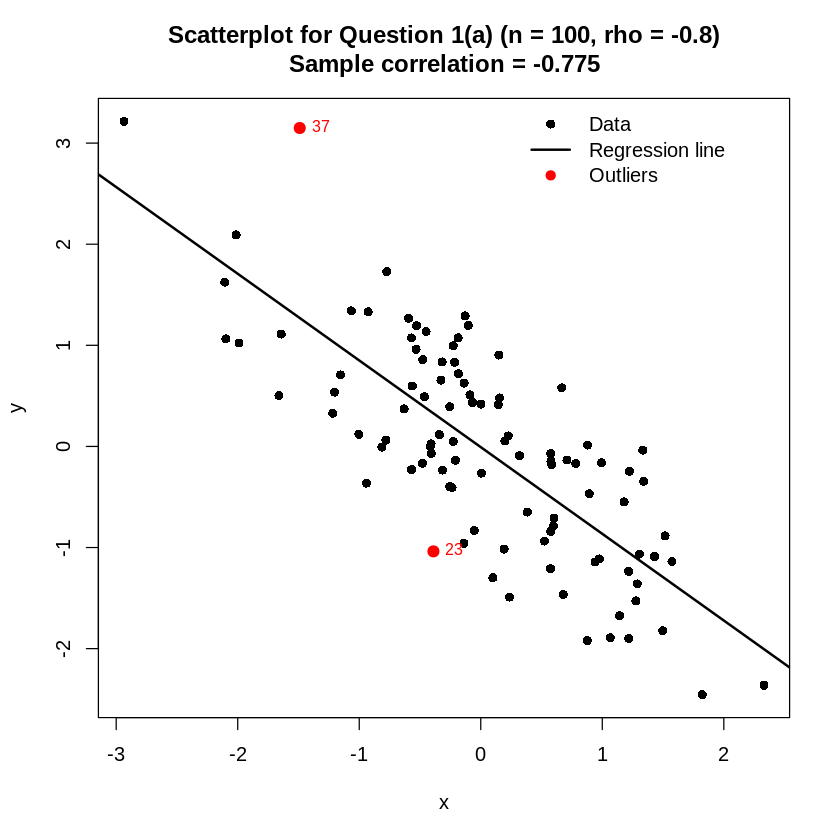

In [ ]:
set.seed(202603)

large_data_1a <- sim_with_rho(rho = -0.8, n = 100)

# sample correlation
r_1a <- cor(large_data_1a$x, large_data_1a$y)

# fit linear regression
fit_1a <- lm(y ~ x, data = large_data_1a)

# identify outliers using standardized residuals
std_resid_1a <- rstandard(fit_1a)
outliers_1a <- which(abs(std_resid_1a) > 2)

# plot all points
plot(large_data_1a$x, large_data_1a$y,
     main = paste0("Scatterplot for Question 1(a) (n = 100, rho = -0.8)\n",
                   "Sample correlation = ", round(r_1a, 3)),
     xlab = "x", ylab = "y",
     pch = 16)

# add regression line
abline(fit_1a, lwd = 2)

# highlight outliers
points(large_data_1a$x[outliers_1a], large_data_1a$y[outliers_1a],
       pch = 19, col = "red", cex = 1.2)

# label outliers by row number
text(large_data_1a$x[outliers_1a], large_data_1a$y[outliers_1a],
     labels = outliers_1a, pos = 4, cex = 0.8, col = "red")

# add legend
legend("topright",
       legend = c("Data", "Regression line", "Outliers"),
       pch = c(16, NA, 19),
       lty = c(NA, 1, NA),
       lwd = c(NA, 2, NA),
       col = c("black", "black", "red"),
       bty = "n")

cor(large_data$x, large_data$y)

Comments:

The scatterplot shows a strong negative linear association between x and y, which is consistent with the specified correlation ρ<sub>XY</sub> = -0.8. The sample correlation is -0.78, close to -0.8, so the simulation function appears to be working as intended.

(b) new function and hypothesis test t_test_rho <- function(x, y, alpha)

In [ ]:
set.seed(202603)

#The function should return 1 if the test rejects H0 and 0 otherwise.
t_test_rho <- function(x, y, alpha) {
  r <- cor(x, y)
  n <- length(x)
  t <- (r * sqrt(n - 2)) / sqrt(1 - r^2)
  p <- 1 - pt(t, df = n - 2)
  return(1 * (p < alpha))  # Converts TRUE/FALSE to 1/0
}

# Run the function with the example data (example data) and α = 0.05.
t_test_rho(example_data$x, example_data$y, 0.05)


[1] 0

(c) t_test_rejections= function(S,rho,n,alpha), for S times, with r,n,alpha are certain values

In [ ]:
set.seed(202603)
# `data` is an intermediate and replicate( ) employed
t_test_rejections <- function(S, rho, n, alpha) {
  rejections <- replicate(S, {
    data <- sim_with_rho(rho, n)
    t_test_rho(data$x, data$y, alpha)
  })
  return(rejections)
}

#Run the function with S = 10, ρ = 0, n = 10 and α = 0.10 to check if it works.
t_test_rejections(10,0,10,0.10)

[1] 0 0 0 0 0 0 0 0 0 1

(d)

In [ ]:
set.seed(202603)

rej_rho_0   <- t_test_rejections(S = 10000, rho = 0,    n = 5, alpha = 0.05)
rej_rho_05  <- t_test_rejections(S = 10000, rho = 0.5,  n = 5, alpha = 0.05)
rej_rho_n08 <- t_test_rejections(S = 10000, rho = -0.8, n = 5, alpha = 0.05)

mean(rej_rho_0)
mean(rej_rho_05)
mean(rej_rho_n08)

[1] 0.0483

[1] 0.2232

[1] 0.0011

When rho<sub>XY</sub> = 0, the null hypothesis is true, so the rejection rate estimates the Type I error rate. Since the estimated rejection probability is close to 0.05, the test appears to control the Type I error rate at the nominal significance level.

When rho<sub>XY</sub> = 0.5, the null hypothesis is false and the alternative hypothesis is true, so the rejection rate estimates the power of the test. Here the power is only about 0.23, which means the Type II error rate is about 1 - 0.23 = 0.77. This indicates that with such a small sample size (n = 5), the test has low power to detect a moderate positive correlation.

When rho<sub>XY</sub> = -0.8, the true correlation is strongly negative, so the one-sided test H0: rho<sub>XY</sub> = 0 versus H1: rho<sub>XY</sub> > 0 should almost never reject H0. The very small rejection rate is therefore expected, since the data go in the opposite direction to the alternative hypothesis.

In [ ]:
set.seed(202603)

rej_rho_0_n100   <- t_test_rejections(S = 10000, rho = 0,    n = 100, alpha = 0.05)
rej_rho_05_n100  <- t_test_rejections(S = 10000, rho = 0.5,  n = 100, alpha = 0.05)
rej_rho_n08_n100 <- t_test_rejections(S = 10000, rho = -0.8, n = 100, alpha = 0.05)

mean(rej_rho_0_n100)
mean(rej_rho_05_n100)
mean(rej_rho_n08_n100)

[1] 0.0481

[1] 0.9999

[1] 0

For n = 100, S = 10000, and alpha = 0.05, the estimated probabilities of rejecting H0 are approximately:

- rho<sub>XY</sub> = 0: 0.05
- rho<sub>XY</sub> = 0.5: 1.00
- rho<sub>XY</sub> = -0.8: 0.00

When rho<sub>XY</sub> = 0, the null hypothesis is true, so the rejection rate estimates the Type I error rate. This remains close to 0.05, showing that the test still controls the Type I error rate at the nominal significance level.

When rho<sub>XY</sub> = 0.5, the null hypothesis is false and the alternative hypothesis is true, so the rejection rate estimates the power of the test. For n = 100, this rejection probability is much higher than it was for n = 5, so the Type II error rate is much lower. This is because a larger sample size gives a more precise estimate of the correlation and makes it easier to detect a true positive association.

When rho<sub>XY</sub> = -0.8, the true correlation is strongly negative, which is in the opposite direction to the alternative hypothesis H1: rho<sub>XY</sub> > 0. Therefore, the test almost never rejects H0. This is expected, and it becomes even more pronounced when n is larger because the sample correlation is estimated more accurately.

To summarize, compared with n = 5, increasing the sample size to n = 100 leaves the Type I error rate approximately unchanged at alpha = 0.05, but greatly reduces the Type II error rate when rho<sub>XY</sub> > 0. This happens because larger samples reduce sampling variability and increase the power of the test, which means we are likely to gain reliable conclusions for a larger dataset.